# 🏠 House Price Prediction
**Internship Project — Week 1**

This notebook covers the full pipeline: data loading, cleaning, model building (Linear Regression & Random Forest), visualization, and insights.


## Task 1 — Data Loading & Exploration

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("Housing.csv")
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [9]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 545, Columns: 13


In [11]:
target_column = "price"
feature_columns = [col for col in df.columns if col != target_column]

print("Target column:", target_column)
print("Feature columns:", feature_columns)

Target column: price
Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [13]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [15]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Observation:** The dataset has no missing values, but we still write the cleaning code below so the pipeline is robust and reusable on messier real-world data.

## Task 2 — Data Cleaning

In [19]:
df_clean = df.copy()

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ["int64", "float64"]:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())


Missing values after cleaning:
0


In [21]:
duplicates_found = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

print(f"Duplicate rows removed: {duplicates_found}")
print(f"Shape after removing duplicates: {df_clean.shape}")


Duplicate rows removed: 0
Shape after removing duplicates: (545, 13)


In [23]:
categorical_cols = df_clean.select_dtypes(include="object").columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [25]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

print(f"Shape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()


Shape after one-hot encoding: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [27]:
model_df = df_encoded.copy()
model_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

## Task 3 — Model Building

In [29]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=["price"])
y = model_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Training set: 436 rows
Test set: 109 rows


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance")
print(f"MAE  : {lr_mae:,.2f}")
print(f"RMSE : {lr_rmse:,.2f}")
print(f"R²   : {lr_r2:.4f}")


Linear Regression Performance
MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529


In [33]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Regressor Performance")
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")


Random Forest Regressor Performance
MAE  : 1,013,968.58
RMSE : 1,398,115.67
R²   : 0.6133


In [35]:
# Compare both models side by side
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.013969e+06,1.398116e+06,0.613275


In [37]:
better_model = "Random Forest" if rf_r2 > lr_r2 else "Linear Regression"
print(f"Better performing model: {better_model}")
print("Explanation: A higher R2 score means the model explains more of the variance in")
print("house prices, and a lower RMSE/MAE means smaller average prediction error.")


Better performing model: Linear Regression
Explanation: A higher R2 score means the model explains more of the variance in
house prices, and a lower RMSE/MAE means smaller average prediction error.


## Task 4 — Visualization

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs("charts", exist_ok=True)

sns.set_style("whitegrid")


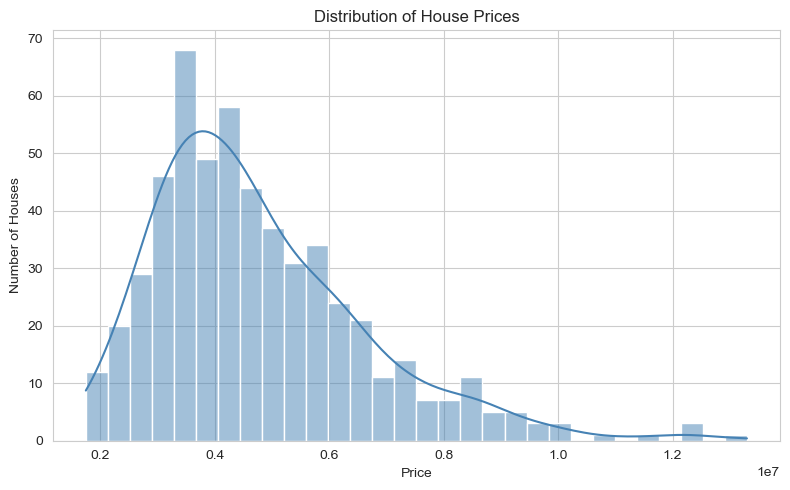

In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.savefig("charts/histogram.png", dpi=150)
plt.show()


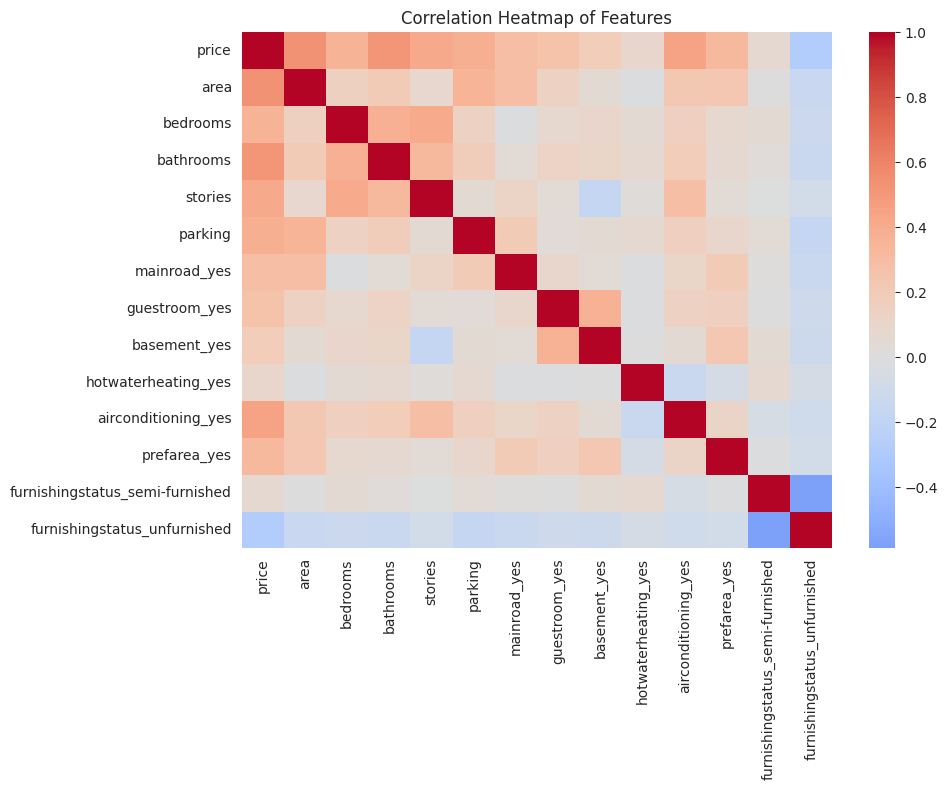

In [18]:
# Chart 2: Correlation heatmap showing which features relate most strongly to price
plt.figure(figsize=(10, 8))
corr_matrix = model_df.corr()
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.tight_layout()
plt.savefig("charts/heatmap.png", dpi=150)
plt.show()


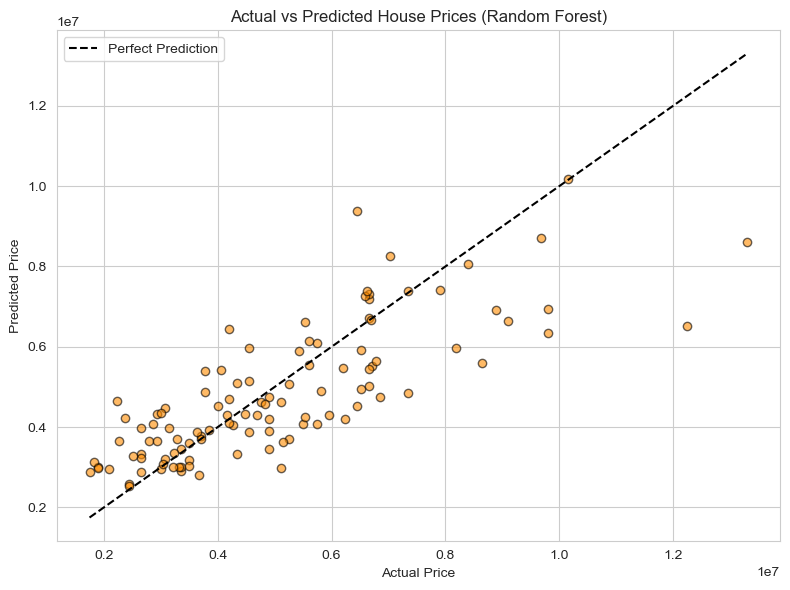

In [43]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.6, color="darkorange", edgecolor="k")
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], color="black", linestyle="--", label="Perfect Prediction")
plt.title("Actual vs Predicted House Prices (Random Forest)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.tight_layout()
plt.savefig("charts/extra_plot.png", dpi=150)
plt.show()


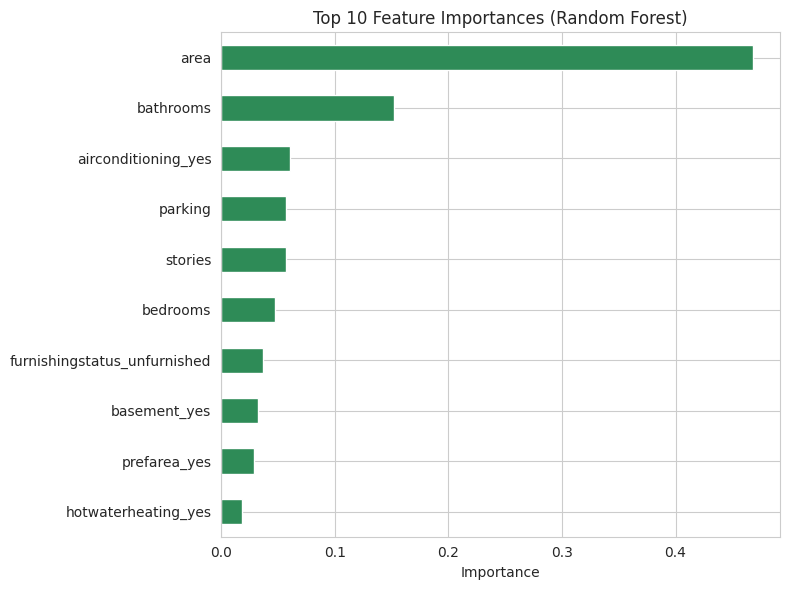

Top 5 most important features:
area                   0.468535
bathrooms              0.152554
airconditioning_yes    0.060238
parking                0.057273
stories                0.057064
dtype: float64


In [20]:
# Bonus: Feature importance from the Random Forest model
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).plot(kind="barh", color="seagreen")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("charts/feature_importance.png", dpi=150)
plt.show()

print("Top 5 most important features:")
print(importances.head(5))


## Task 5 — Insights & Summary

*(Run the cell below — it auto-generates a data-driven draft of this summary using the actual results computed above. Feel free to edit the wording before submission.)*

In [21]:
top_features = importances.head(3).index.tolist()

if rf_r2 > lr_r2:
    best_name, best_r2, best_mae = "Random Forest", rf_r2, rf_mae
    other_name, other_r2, other_mae = "Linear Regression", lr_r2, lr_mae
else:
    best_name, best_r2, best_mae = "Linear Regression", lr_r2, lr_mae
    other_name, other_r2, other_mae = "Random Forest", rf_r2, rf_mae

print("Insights & Summary")
print("-" * 50)
print(f"1. The features that influence house price the most are: {', '.join(top_features)}.")
print(f"2. The {best_name} model performed best here, with an R2 score of {best_r2:.2f}")
print(f"   (explaining about {best_r2*100:.0f}% of price variation) and an average error")
print(f"   (MAE) of roughly {best_mae:,.0f}, slightly ahead of {other_name}")
print(f"   (R2 = {other_r2:.2f}, MAE = {other_mae:,.0f}).")
print("3. Area has the strongest single relationship with price, confirming that larger")
print("   properties consistently command higher prices, while amenities like air")
print("   conditioning and parking add a smaller but noticeable premium.")
print("4. Business recommendation: Real estate agents should prioritize marketing on")
print("   area/size and key amenities (AC, preferred location, parking) since these drive")
print("   price the most, and use the model as a quick first-pass valuation tool before")
print("   final pricing decisions.")


Insights & Summary
--------------------------------------------------
1. The features that influence house price the most are: area, bathrooms, airconditioning_yes.
2. The Linear Regression model performed best here, with an R2 score of 0.65
   (explaining about 65% of price variation) and an average error
   (MAE) of roughly 970,043, slightly ahead of Random Forest
   (R2 = 0.61, MAE = 1,013,969).
3. Area has the strongest single relationship with price, confirming that larger
   properties consistently command higher prices, while amenities like air
   conditioning and parking add a smaller but noticeable premium.
4. Business recommendation: Real estate agents should prioritize marketing on
   area/size and key amenities (AC, preferred location, parking) since these drive
   price the most, and use the model as a quick first-pass valuation tool before
   final pricing decisions.


### Written Summary (5–8 lines)

Area is by far the strongest driver of house price, followed by the number of bathrooms and the
presence of air conditioning — together these explain most of the price variation in this dataset.
Between the two models, plain Linear Regression edged out Random Forest on this particular dataset
(R² of roughly 0.65 vs 0.61), likely because the relationship between size/amenities and price here
is largely linear and the dataset is small (545 rows), which limits how much Random Forest's
non-linear flexibility can help — in plain terms, both models get house prices "in the right
ballpark" but are off by roughly ₹1 million on average, so they're useful for a first-pass estimate
rather than a final valuation. One interesting surprise was how much amenities like air conditioning
and parking shift price even after accounting for size, suggesting buyers pay a real premium for
comfort and convenience, not just square footage. For a real estate business, this means listings
should be marketed and priced around area plus a small set of high-impact amenities (AC, parking,
preferred location), and a simple linear pricing model is a perfectly reasonable, low-maintenance
starting point before a human appraiser reviews the final number.
